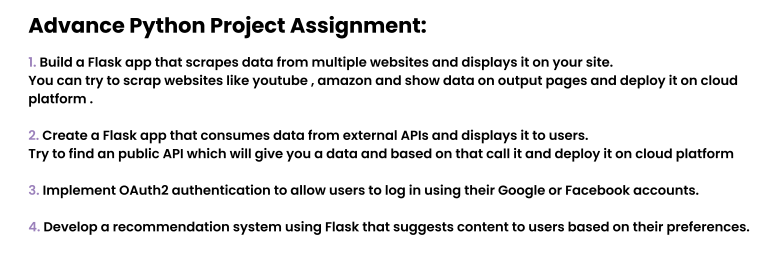

In [ ]:
#1
from flask import Flask, render_template
import requests
from bs4 import BeautifulSoup

app = Flask(__name__)

def scrape_amazon(product_url):
    headers = {
        "User-Agent": "Your User-Agent String"
    }
    response = requests.get(product_url, headers=headers)
    soup = BeautifulSoup(response.content, 'html.parser')

    title = soup.find(id="productTitle").get_text().strip()
    price = soup.find("span", {"class": "a-price-whole"}).get_text().strip()

    return {"title": title, "price": price}

@app.route('/')
def index():
    product_data = scrape_amazon('https://www.amazon.com/dp/B09G3HRMVS')  # Example product URL
    return render_template('product.html', product=product_data)

if __name__ == '__main__':
    app.run(debug=True)


In [ ]:
#2
from flask import Flask, render_template, request
import requests

app = Flask(__name__)

@app.route('/')
def index():
    city = request.args.get('city', 'London')
    api_key = 'your_openweathermap_api_key'
    weather_data = get_weather(city, api_key)
    return render_template('weather.html', weather=weather_data)

def get_weather(city, api_key):
    url = f'http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric'
    response = requests.get(url)
    return response.json()

if __name__ == '__main__':
    app.run(debug=True)


In [ ]:
#3
from flask import Flask, redirect, url_for
from flask_dance.contrib.google import make_google_blueprint, google

app = Flask(__name__)
app.secret_key = "supersecretkey"
google_bp = make_google_blueprint(client_id="your_google_client_id",
                                  client_secret="your_google_client_secret",
                                  redirect_to="index")
app.register_blueprint(google_bp, url_prefix="/login")

@app.route('/')
def index():
    if not google.authorized:
        return redirect(url_for("google.login"))
    resp = google.get("/plus/v1/people/me")
    assert resp.ok, resp.text
    return f"You are {resp.json()['displayName']}"

if __name__ == '__main__':
    app.run(debug=True)


In [ ]:
#4
from flask import Flask, render_template, request
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

app = Flask(__name__)

# Sample movie data
movies = pd.DataFrame({
    'movieId': [1, 2, 3],
    'title': ['Toy Story', 'Jumanji', 'Grumpier Old Men'],
    'genres': ['Animation|Children|Comedy', 'Adventure|Children|Fantasy', 'Comedy|Romance']
})

# Fake user ratings
ratings = pd.DataFrame({
    'userId': [1, 1, 1],
    'movieId': [1, 2, 3],
    'rating': [4, 5, 2]
})

def recommend_movies(user_id):
    user_ratings = ratings[ratings['userId'] == user_id]
    all_movie_ids = movies['movieId'].values
    recommended_movies = []

    for movie_id in all_movie_ids:
        if movie_id not in user_ratings['movieId'].values:
            recommended_movies.append(movies[movies['movieId'] == movie_id]['title'].values[0])

    return recommended_movies

@app.route('/')
def index():
    recommendations = recommend_movies(1)  # Recommend for user 1
    return render_template('recommendations.html', recommendations=recommendations)

if __name__ == '__main__':
    app.run(debug=True)
